In [75]:
#--- Task: Did Bronx Science High School students score better than other high schools in NYC on their Chemistry Regents in 2016? ---

In [1]:
#--- Install Necessary databases ---

!mamba install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.6375 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.2.25                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.11                          pyhd8ed1ab_0                  conda-forge                   
+ joblib                        1.5.3   

In [2]:
#--- Install Necessary databases ---

import pandas as pd

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv')

In [4]:
#--- Confirm what fields are included in the dataframe ---

df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [52]:
#--- Check total number of rows/columns in original dataframe ---

print(df['Number Scoring 80 or Above'].sort_values().unique())

<StringArray>
[   '0',    '1',   '10',  '100', '1005',  '101', '1010',  '102', '1023',
  '103',
 ...
  '959',   '96',  '967',   '97',  '972',  '978',   '98',   '99',  '997',
    's']
Length: 744, dtype: str


In [104]:
#--- filter out null/'s' values ---

df = df[df['Number Scoring 80 or Above'] != 's']

print(df['Number Scoring 80 or Above'].sort_values().unique())

[   0    1    2    3    4    5    6    7    8    9   10   11   12   13
   14   15   16   17   18   19   20   21   22   23   24   25   26   27
   28   29   30   31   32   33   34   35   36   37   38   39   40   41
   42   43   44   45   46   47   48   49   50   51   52   53   54   55
   56   57   58   59   60   61   62   63   64   65   66   67   68   69
   70   71   72   73   74   75   76   77   78   79   80   81   82   83
   84   85   86   87   88   89   90   91   92   93   94   95   96   97
   98   99  100  101  102  103  104  105  106  107  108  109  110  111
  112  113  114  115  116  117  118  119  120  121  122  123  124  125
  126  127  128  129  130  131  132  133  134  135  136  137  138  139
  140  141  142  143  144  145  146  147  148  149  150  151  152  153
  154  155  156  157  158  159  160  161  162  163  164  165  166  167
  168  169  170  171  172  173  174  175  176  177  178  179  180  181
  182  183  184  185  186  187  188  189  190  191  192  193  194  195
  196 

In [105]:
#--- convert necessary values to integers ---

df['Number Scoring 80 or Above'] = df['Number Scoring 80 or Above'].astype(int) 
df['Year'] = df['Year'].astype(str) 

df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
5,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2015,9,67.4,3,33.3,6,66.7,0,0,na,na
6,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2016,15,72.6,2,13.3,13,86.7,5,33.3,na,na
7,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2017,9,64.4,5,55.6,4,44.4,1,11.1,na,na


In [106]:
#--- Create borough-specific data frames for comparison, if needed ---

df_Manhattan=df[df['School DBN'].str.contains('M')]
df_SI=df[df['School DBN'].str.contains('R')]
df_BK=df[df['School DBN'].str.contains('K')]
df_Queens=df[df['School DBN'].str.contains('Q')]
df_Bronx=df[df['School DBN'].str.contains('X')]

In [107]:
#--- Create high school level data-frame for comparison and understand what values are available for comparison ---

df_HS=df[df['School Level'].str.contains('High school')]
df_HS['Regents Exam'].unique()

<StringArray>
[            'Common Core Algebra',            'Common Core Algebra2',
             'Common Core English',            'Common Core Geometry',
                         'English',                        'Geometry',
    'Global History and Geography',              'Integrated Algebra',
              'Living Environment', 'Physical Settings/Earth Science',
     'U.S. History and Government',           'Algebra2/Trigonometry',
     'Physical Settings/Chemistry',       'Physical Settings/Physics']
Length: 14, dtype: str

In [108]:
#--- filter out target regents for comparison: 'Physical Settings/Chemistry' ---

df_HSchem=df_HS[df_HS['Regents Exam']=='Physical Settings/Chemistry']

df_HSchem.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
85,01M448,University Neighborhood High School,High school,Physical Settings/Chemistry,2015,20,60.9,12,60,8,40,0,0,na,na
86,01M448,University Neighborhood High School,High school,Physical Settings/Chemistry,2016,19,65.7,7,36.8,12,63.2,2,10.5,na,na
87,01M448,University Neighborhood High School,High school,Physical Settings/Chemistry,2017,14,63.9,8,57.1,6,42.9,2,14.3,na,na
151,01M509,Marta Valle High School,High school,Physical Settings/Chemistry,2015,15,73.5,2,13.3,13,86.7,5,33.3,na,na
152,01M509,Marta Valle High School,High school,Physical Settings/Chemistry,2017,36,50.5,31,86.1,5,13.9,0,0,na,na


In [81]:
#--- clean up NYC HS dataframe ---

NYHSCHEM=df_HSchem[['School Name', 'Regents Exam', 'Year', 'Total Tested', 'Mean Score', 'Number Scoring 80 or Above']]

NYHSCHEM.head()

,School Name,Regents Exam,Year,Total Tested,Mean Score,Number Scoring 80 or Above
85,University Neighborhood High School,Physical Settings/Chemistry,2015,20,60.9,0
86,University Neighborhood High School,Physical Settings/Chemistry,2016,19,65.7,2
87,University Neighborhood High School,Physical Settings/Chemistry,2017,14,63.9,2
151,Marta Valle High School,Physical Settings/Chemistry,2015,15,73.5,5
152,Marta Valle High School,Physical Settings/Chemistry,2017,36,50.5,0


In [109]:
# --- filter out sum of all 2016 chemistry scores above 80 ---

NYCHSCHEM2016 = NYHSCHEM[NYHSCHEM['Year'] == '2016']

NYCHSCHEM2016_above80 = NYCHSCHEM2016['Number Scoring 80 or Above'].mean()

print(NYCHSCHEM2016_above80)

18.945264452644526


In [87]:
#--- filter out target school for comparison: Bronx Science ---

df_BXS2016chem=NYCHSCHEM2016[NYCHSCHEM2016['School Name'].str.contains('Bronx High School of Science')]

df_BXS2016chem.head()

,School Name,Regents Exam,Year,Total Tested,Mean Score,Number Scoring 80 or Above
6854,Bronx High School of Science,Physical Settings/Chemistry,2016,795,87.1,656
31879,Bronx High School of Science,Physical Settings/Chemistry,2016,787,87.2,653
31880,Bronx High School of Science,Physical Settings/Chemistry,2016,8,75.5,3
71841,Bronx High School of Science,Physical Settings/Chemistry,2016,592,87.3,490
71842,Bronx High School of Science,Physical Settings/Chemistry,2016,203,86.6,166


In [110]:
#--- sum total bronx science students scoring 80 or above ---

df_BXS2016chem_above80 = df_BXS2016chem['Number Scoring 80 or Above'].mean()

print(df_BXS2016chem_above80)

273.3333333333333


In [111]:
# --- compare to total # students scoring above 80 in NYC ---

print(NYCHSCHEM2016_above80)

18.945264452644526


In [ ]:
#--- confirm hypothesis: 273 students on average in bronx science scored 80 or above compared to 18 students on average across all NYC high schools ---


<Axes: xlabel='Year'>

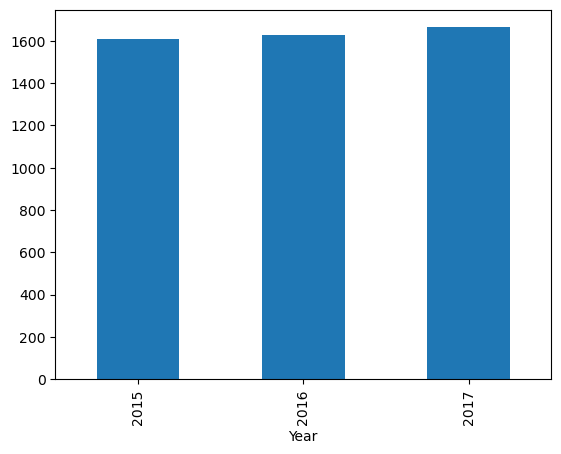

In [114]:
#--- provide visual of number of students scoring 80 or above in NYC by year ---

NYHSCHEM.groupby(['Year'])['Number Scoring 80 or Above'].count().sort_values().plot(kind='bar')